In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv('/home/iclal-sule-agirman/İndirilenler/event-versions.csv')
df_new= df.drop(columns=['shortName', 'gps','version','catalog','doi','detail_url','chirp_mass','chirp_mass_lower','chirp_mass_upper','far_lower','far_upper', 'p_astro_lower','p_astro_upper'])
df_new.to_csv("gw_data.csv", index=False)

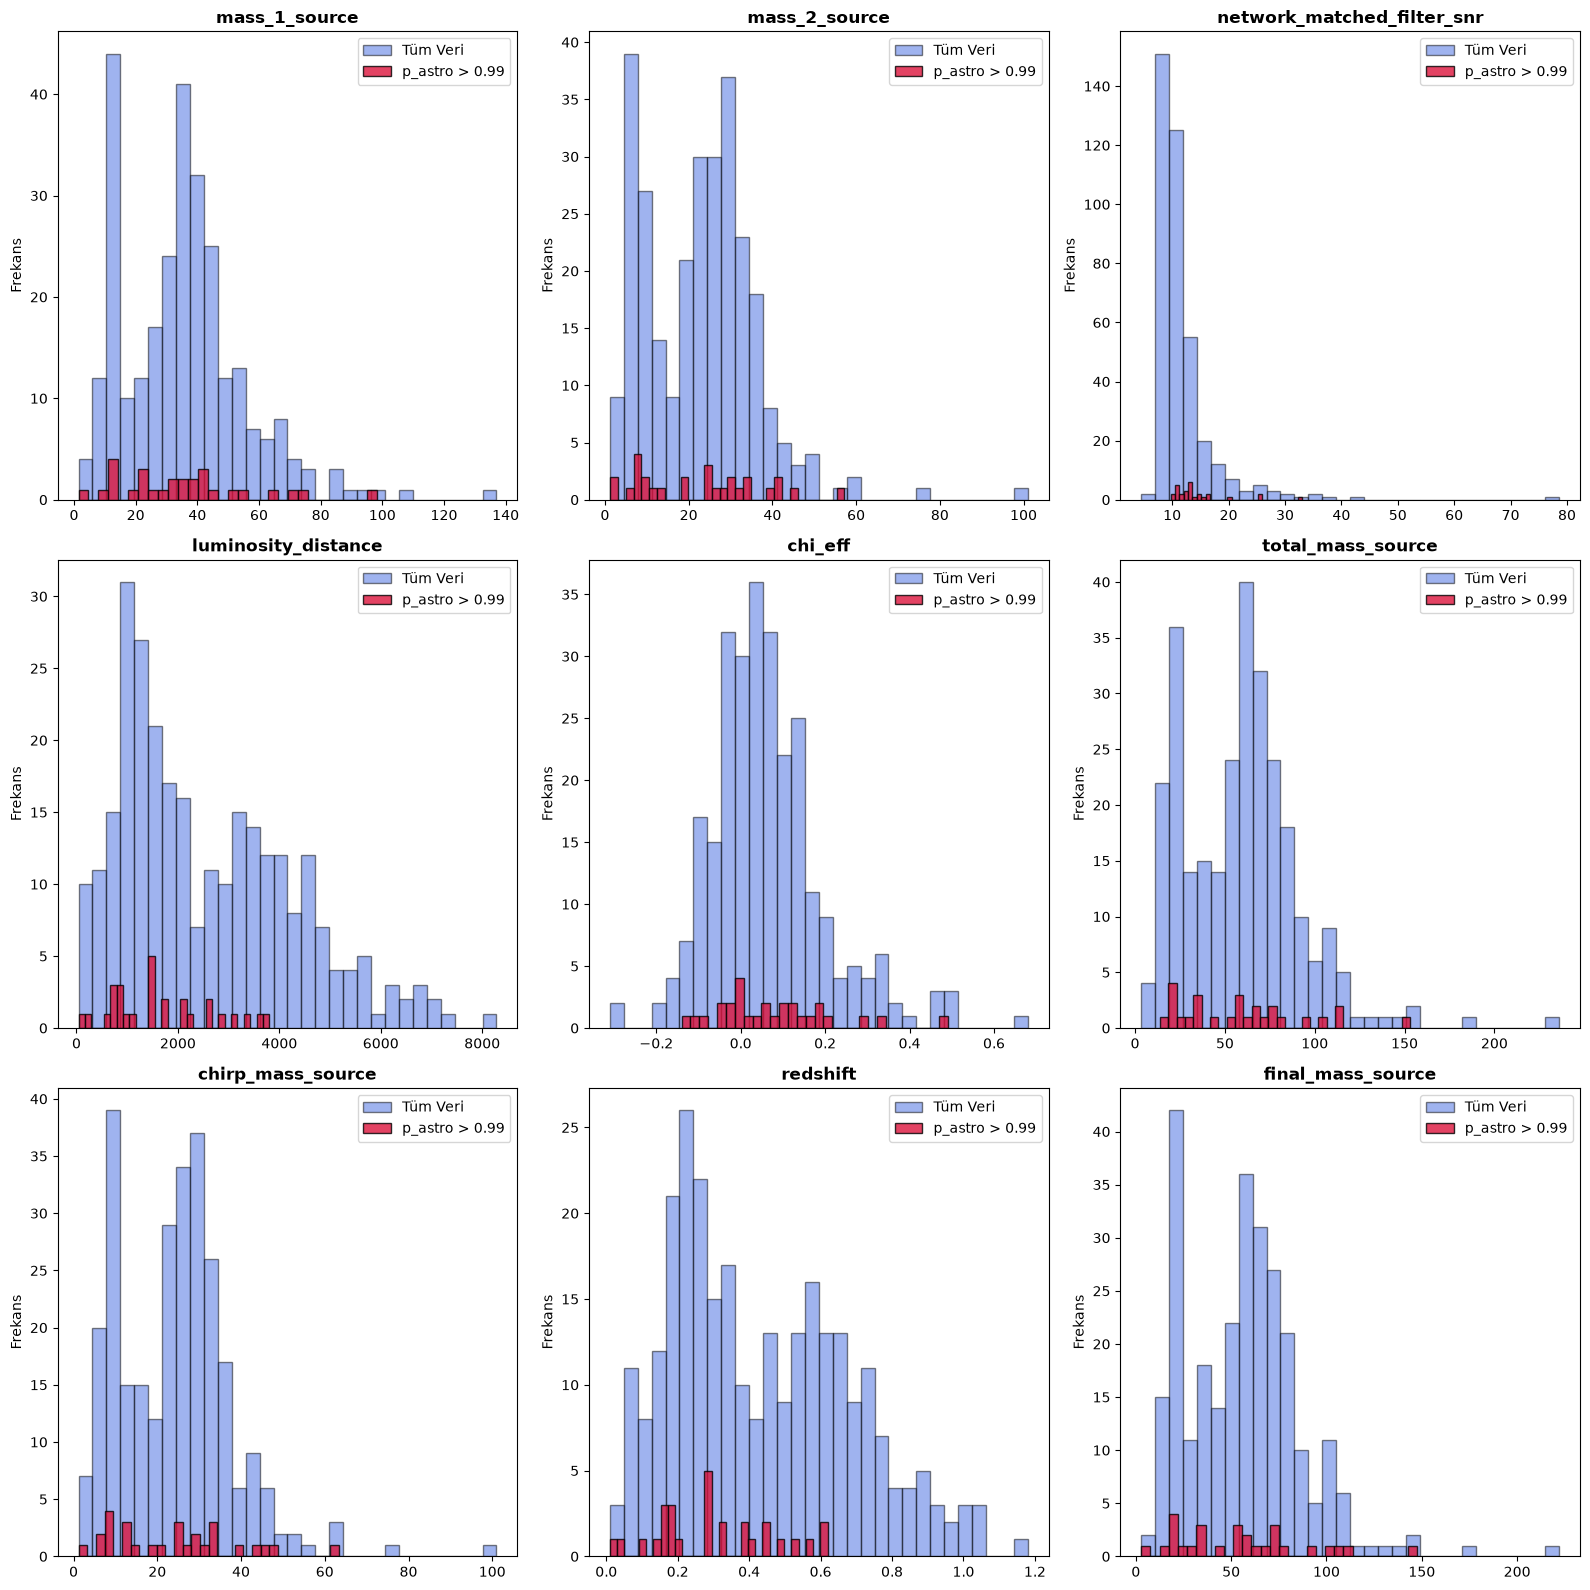

In [14]:

m1 = df_new['mass_1_source']
m2 = df_new['mass_2_source']
snr = df_new['network_matched_filter_snr']
ld = df_new['luminosity_distance']
chi_eff = df_new['chi_eff']
totalm = df_new['total_mass_source']
chirpm = df_new['chirp_mass_source']
red = df_new['redshift']
far = df_new['far']
p_astro = df_new['p_astro']
finalm = df_new['final_mass_source']

#Distributions
parametreler = [
    'mass_1_source', 'mass_2_source', 'network_matched_filter_snr', 
    'luminosity_distance', 'chi_eff', 'total_mass_source', 
    'chirp_mass_source', 'redshift', 'final_mass_source'
]

# p_astro değeri 0.99'dan büyük olanları filtreleyelim
df_p = df_new[df_new['p_astro'] > 0.99]

# 3 satır ve 3 sütundan oluşan figur
fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten() # Döngüde kolay kullanmak için 1 boyutlu diziye çeviriyoruz

for i, param in enumerate(parametreler):
    ax = axes[i]
    
    # 1. Tümü için histogram 
    ax.hist(df_new[param].dropna(), bins=30, color='royalblue', alpha=0.5, 
            edgecolor='black', label='Tüm Veri')
    
    # 2. Sadece p_astro > 0.99 olanlar için histogram (Ön planda, kırmızı)
    ax.hist(df_p[param].dropna(), bins= 30, color='crimson', alpha=0.8, 
            edgecolor='black', label='p_astro > 0.99')
    
    # Grafiği isimlendirme ve etiketleme
    ax.set_title(param, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frekans')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


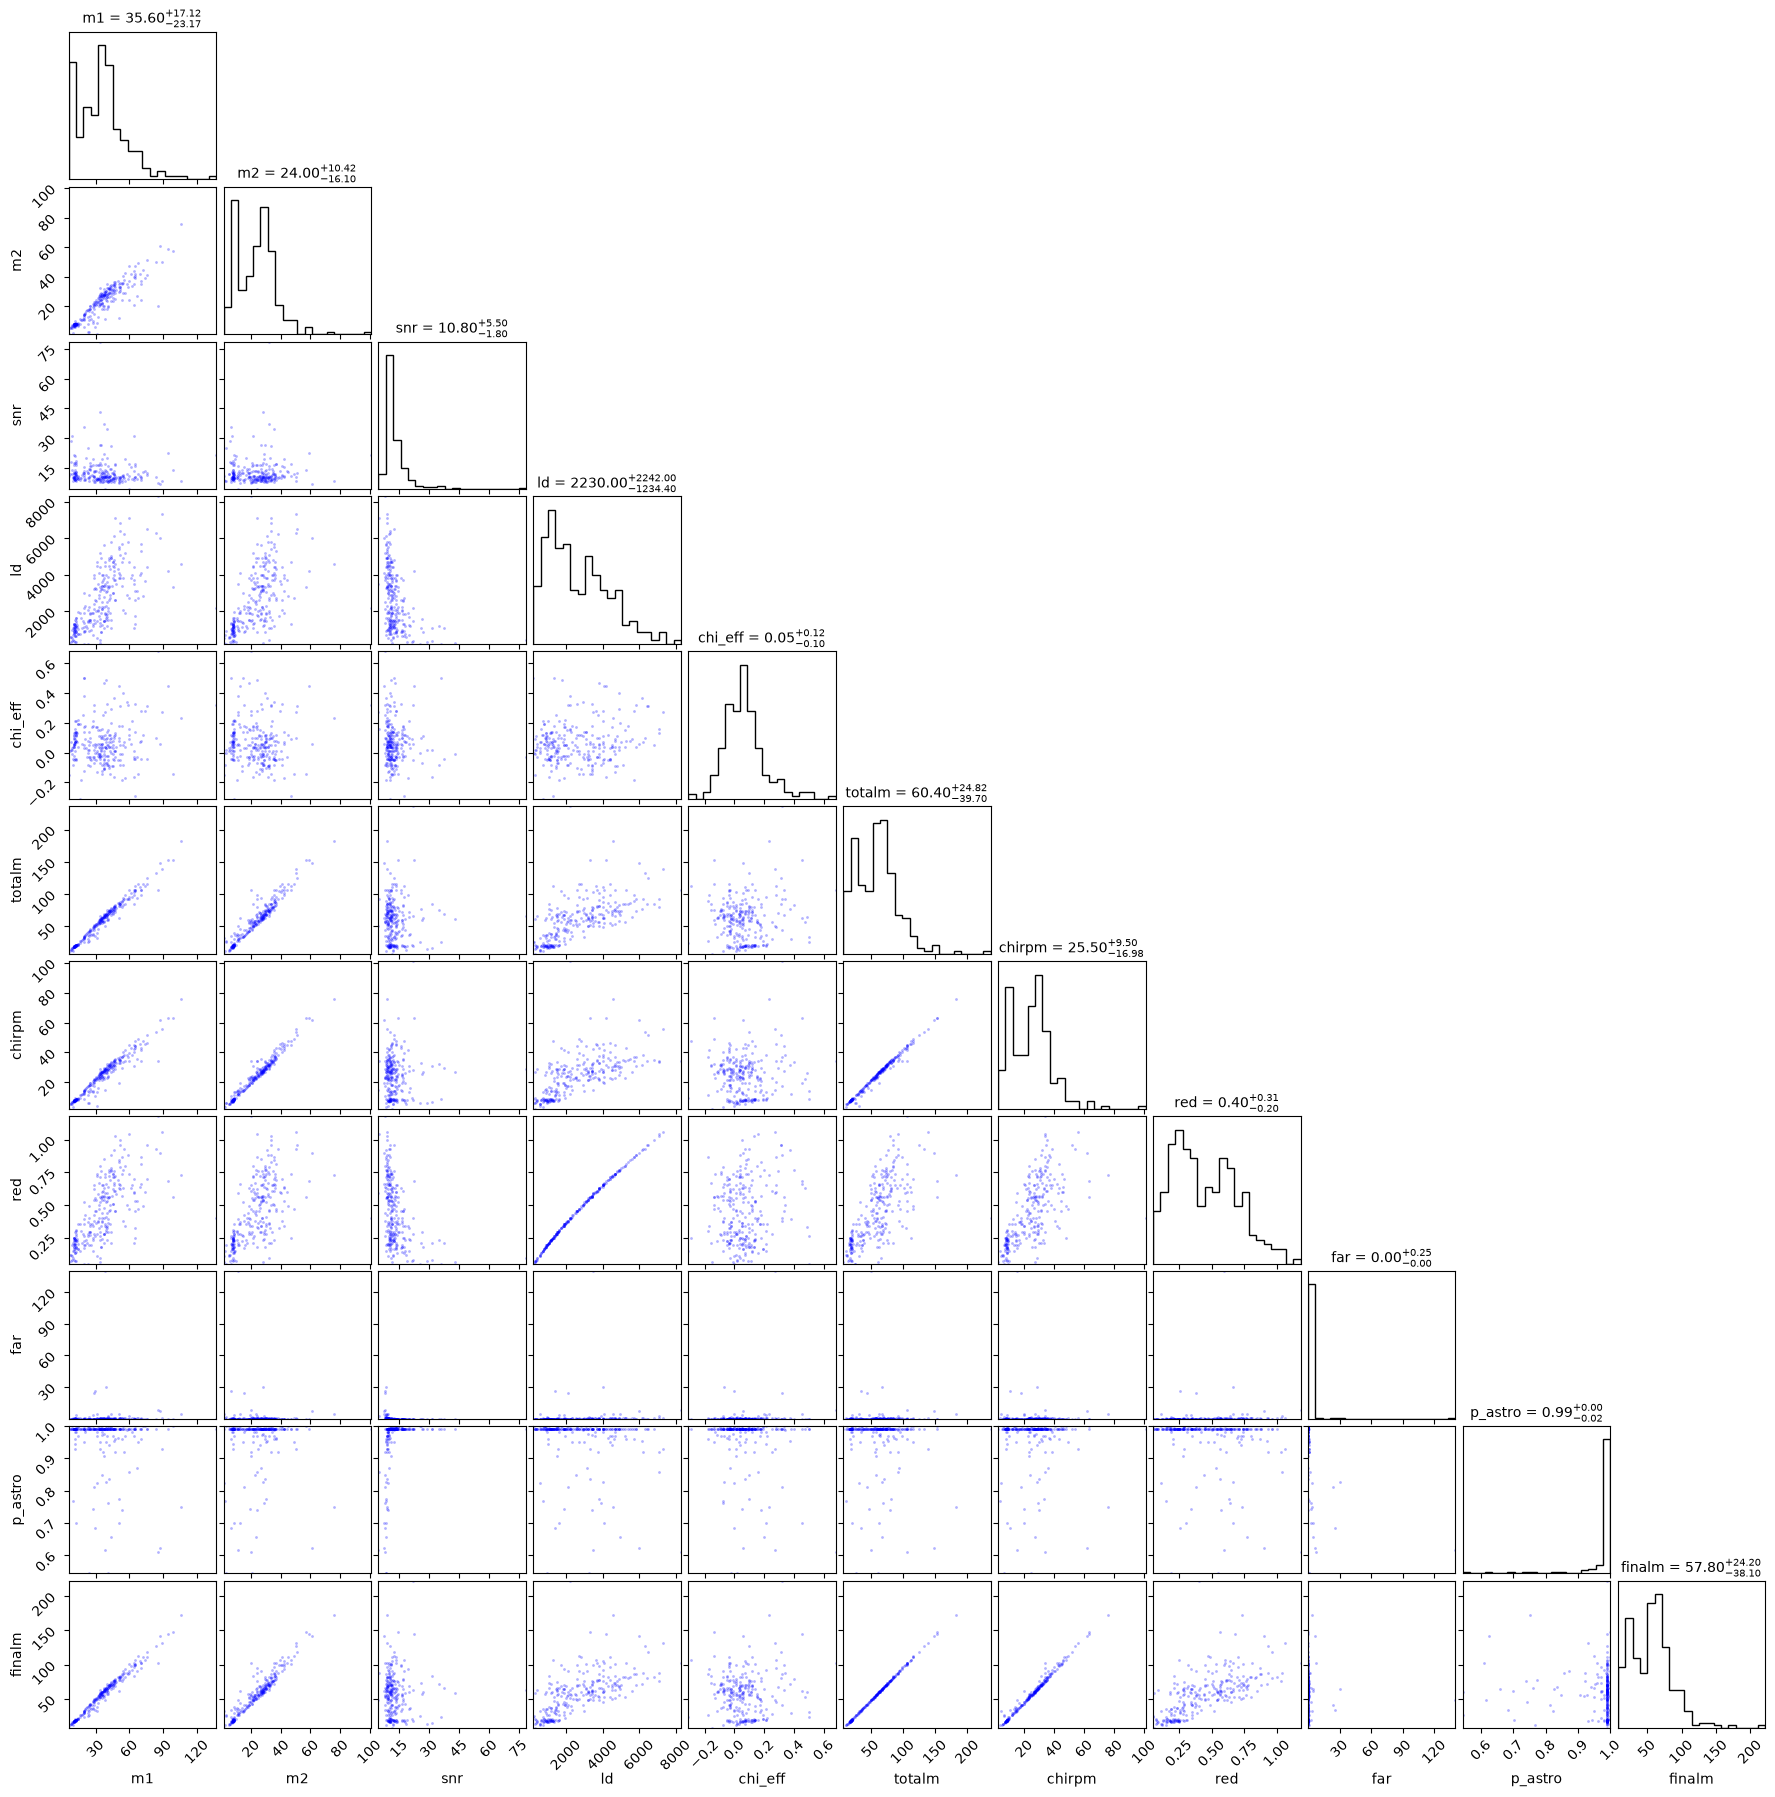

In [17]:
import corner

degiskenler = [
    'mass_1_source', 'mass_2_source', 'network_matched_filter_snr', 
    'luminosity_distance', 'chi_eff', 'total_mass_source', 
    'chirp_mass_source', 'redshift', 'far', 'p_astro', 'final_mass_source'
]

table_labels = [
    'm1', 'm2', 'snr', 'ld', 'chi_eff', 
    'totalm', 'chirpm', 'red', 'far', 'p_astro', 'finalm'
]
# Sadece bu sütunları seç ve eksik verileri temizle
df_plot = df_new[degiskenler].dropna()

# GRAFİĞİ ÇİZDİRME 
fig = corner.corner(
    df_plot, 
    labels= table_labels,
    show_titles=True,
    title_kwargs={"fontsize": 10}, 
    
    plot_contours=False,   # Hata veren kontur çizgilerini kapattık
    plot_density=False,    # Çok sıkışık yerleri düz renge boyamayı kapattık
    plot_datapoints=True,  # Sadece gerçek veri noktalarını (scatter) göstersin
    
    # Noktalar çok iç içe geçeceği için ufak ve hafif saydam yaptık:
    data_kwargs={"alpha": 0.3, "color": "blue"}, 
    
    # Eksen etiketlerini daha okunaklı yapmak için:
    label_kwargs={"fontsize": 10} 
)


fig.set_size_inches(18, 18) 
plt.show()



In [18]:

#Korelasyon matrisi
df_korelasyon = df_new[degiskenler].dropna()
korelasyon_matrisi = df_korelasyon.corr()
print(korelasyon_matrisi)

                            mass_1_source  mass_2_source  \
mass_1_source                    1.000000       0.912361   
mass_2_source                    0.912361       1.000000   
network_matched_filter_snr      -0.051960       0.049963   
luminosity_distance              0.664108       0.584473   
chi_eff                          0.126913      -0.001773   
total_mass_source                0.987099       0.965514   
chirp_mass_source                0.965417       0.986337   
redshift                         0.672426       0.600106   
far                              0.023001      -0.060602   
p_astro                         -0.152304       0.018368   
final_mass_source                0.988120       0.963696   

                            network_matched_filter_snr  luminosity_distance  \
mass_1_source                                -0.051960             0.664108   
mass_2_source                                 0.049963             0.584473   
network_matched_filter_snr                